In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns

# Data Features

Dataset: https://raw.githubusercontent.com/csbfx/cs133/main/sf_bayarea_house_prices.csv

Address - the address of the house

City - the city the house is at

State - California, this data set is from the Bay Area

Zip - postal zip code

Price - listing price of the house

Beds - number of bedrooms

Baths - number of bathrooms

Home size - the square footage of the house

Lot size - the square footage of the lot

Latitude - latitude coordinate

Longitude - longitude coordinate

SF time - the commute time by car at 8 AM to San Francisco

PA time - the commute time by car at 8 AM to commute to Palo Alto

School score - the quality of the schools in the neighborhood

Commute time - the commute time by car at 8 AM to the general Bay Area



# Data Description

In [2]:
# Load data
data='https://raw.githubusercontent.com/csbfx/cs133/main/sf_bayarea_house_prices.csv'
df = pd.read_csv(data)
df.head()

,Address,City,State,Zip,Price,Beds,Baths,Home size,Lot size,Latitude,Longitude,SF time,PA time,School score,Commute time
0,2412 Palmer Ave,Belmont,CA,94002,1459000,3,2.0,1360.0,5001.0,37.516781,-122.304623,63,33,77.9,33
1,1909 Hillman Ave,Belmont,CA,94002,1595000,4,2.0,2220.0,3999.0,37.521972,-122.294079,63,33,77.9,33
2,641 Waltermire St,Belmont,CA,94002,899999,2,1.0,840.0,4234.0,37.520233,-122.273144,63,33,77.9,33
3,2706 Sequoia Way,Belmont,CA,94002,1588000,3,2.0,1860.0,5210.0,37.520192,-122.309437,63,33,77.9,33
4,1568 Winding Way,Belmont,CA,94002,1999000,4,3.5,2900.0,16117.2,37.524280,-122.291241,63,33,77.9,33


In [3]:
total_houses = len(df)
total_houses

7145

In [4]:
for i in df.columns.tolist():
    print(i, end=', ')

Address, City, State, Zip, Price, Beds, Baths, Home size, Lot size, Latitude, Longitude, SF time, PA time, School score, Commute time, 

In [5]:
# Check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7145 entries, 0 to 7144
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Address       7137 non-null   object 
 1   City          7145 non-null   object 
 2   State         7145 non-null   object 
 3   Zip           7145 non-null   int64  
 4   Price         7145 non-null   int64  
 5   Beds          7145 non-null   int64  
 6   Baths         7145 non-null   float64
 7   Home size     7063 non-null   float64
 8   Lot size      6880 non-null   float64
 9   Latitude      7145 non-null   float64
 10  Longitude     7145 non-null   float64
 11  SF time       7145 non-null   int64  
 12  PA time       7145 non-null   int64  
 13  School score  7085 non-null   float64
 14  Commute time  7145 non-null   int64  
dtypes: float64(6), int64(6), object(3)
memory usage: 837.4+ KB


In [6]:
# Describe data
df.describe()

,Zip,Price,Beds,Baths,Home size,Lot size,Latitude,Longitude,SF time,PA time,School score,Commute time
count,7145.000000,7.145000e+03,7145.000000,7145.000000,7063.000000,6.880000e+03,7145.000000,7145.000000,7145.000000,7145.000000,7085.000000,7145.000000
mean,94610.732120,1.676225e+06,3.594822,2.572498,2244.186040,2.807283e+04,37.692989,-122.124319,83.335899,83.850385,52.669273,67.370749
std,343.763512,2.407593e+06,1.030743,1.127692,1369.340525,3.215086e+05,0.262637,0.238086,27.048451,34.195327,20.007771,29.160700
min,94002.000000,1.290000e+05,1.000000,1.000000,107.000000,4.360000e+02,37.150065,-122.698597,8.000000,5.000000,17.100000,5.000000
25%,94509.000000,7.299500e+05,3.000000,2.000000,1408.000000,4.850750e+03,37.450607,-122.281695,65.000000,60.000000,33.800000,47.000000
50%,94572.000000,1.099988e+06,4.000000,2.500000,1904.000000,6.477000e+03,37.741127,-122.117378,90.000000,85.000000,50.900000,63.000000
75%,94920.000000,1.699000e+06,4.000000,3.000000,2646.500000,1.001880e+04,37.915970,-121.951238,100.000000,110.000000,71.000000,90.000000
max,95391.000000,4.999000e+07,13.000000,11.000000,20982.000000,1.364561e+07,38.149218,-121.503746,170.000000,150.000000,89.800000,135.000000


# Data Quality

## Check duplicates

In [7]:
# Check duplicates
print("Duplicates =", df.duplicated().sum())

Duplicates = 1191


In [8]:
# Check if duplicates are exact copies or have some differences
exact_dupes = df[df.duplicated(keep=False)].sort_values(list(df.columns))
exact_dupes.head()

,Address,City,State,Zip,Price,Beds,Baths,Home size,Lot size,Latitude,Longitude,SF time,PA time,School score,Commute time
2890,081 Arreba St,Martinez,CA,94553,615000,3,2.0,1754.0,5000.0,38.008264,-122.137730,100,130,43.3,100
2945,081 Arreba St,Martinez,CA,94553,615000,3,2.0,1754.0,5000.0,38.008264,-122.137730,100,130,43.3,100
2990,081 Arreba St,Martinez,CA,94553,615000,3,2.0,1754.0,5000.0,38.008264,-122.137730,100,130,43.3,100
1290,1 Cielito Dr,San Francisco,CA,94134,689000,3,2.0,1304.0,2178.0,37.710154,-122.421495,30,65,32.9,30
1319,1 Cielito Dr,San Francisco,CA,94134,689000,3,2.0,1304.0,2178.0,37.710154,-122.421495,30,65,32.9,30


These 1191 duplicates are mostly real exact row duplicates

In [9]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [10]:
# Inspect rows that share the same address key
addr_cols = ['Address', 'City', 'State', 'Zip']

same_address = df[df.duplicated(subset=addr_cols, keep=False)].sort_values(addr_cols)
same_address[['Address', 'City', 'State', 'Zip', 'Price', 'Beds', 'Baths', 'Home size', 'Lot size']].head()

,Address,City,State,Zip,Price,Beds,Baths,Home size,Lot size
382,1019 Los Trancos Rd,Portola Valley,CA,94028,1595000,3,1.5,1180.0,9361.0
404,1019 Los Trancos Rd,Portola Valley,CA,94028,1595000,3,1.5,1180.0,9360.0
383,116 Russell Ave,Portola Valley,CA,94028,1895000,3,2.0,1821.0,5998.0
411,116 Russell Ave,Portola Valley,CA,94028,1895000,3,2.0,1821.0,6000.0
329,1175 Osborn Ave,Atherton,CA,94027,2149888,3,3.0,1705.0,7819.0


In [11]:
# Keep only one row per address
df = df.drop_duplicates(subset=addr_cols, keep='first')
print("Houses after all removals =", len(df))

# Total duplicates
print("Total duplicates =", total_houses - len(df))

Houses after all removals = 5927
Total duplicates = 1218


## Check missing values

In [12]:
# Check missing values
df.isnull().sum()

,0
Address,5
City,0
State,0
Zip,0
Price,0
Beds,0
Baths,0
Home size,72
Lot size,210
Latitude,0


In [13]:
# Drop missing addresses
df.dropna(subset=['Address'], inplace=True)

In [14]:
# Function to plot histogram
def show_histogram(title,
                   x_label, y_label,
                   values):
    sns.histplot(values, kde=True)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(axis='y')
    plt.show()

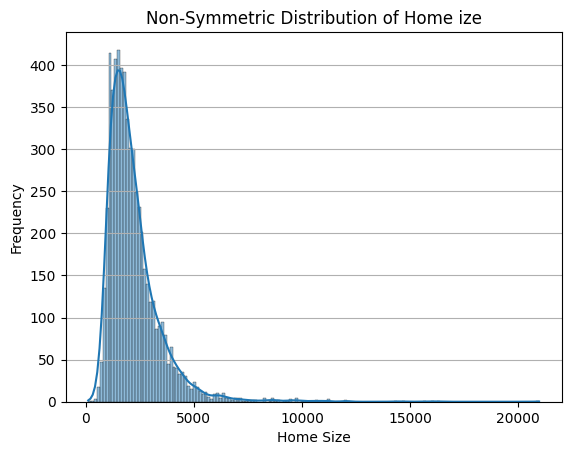

In [15]:
# Plot histogram distribution of Home size
show_histogram("Non-Symmetric Distribution of Home ize", "Home Size", "Frequency", df['Home size'])

Interpretation:

The histogram shows a non-symmetric distribution for `Home size`. It is a right-skewed shape with most homes clustering around 1,000–3,000 sq ft, while a few larger ones, up to 20,000 sq ft, create a long tail on the right.

Therefore, the median is a more appropriate missing value imputation technique than the mean. The reason is that the median is more resistant to outliers and skewed data.

In [16]:
# Fill missing values by using their citis' median beacuse of non-symmetric distribution
df['Home size'] = df.groupby('City')['Home size'].transform(lambda x: x.fillna(x.median()))
df['Lot size'] = df.groupby('City')['Lot size'].transform(lambda x: x.fillna(x.median()))
df['School score'] = df.groupby('City')['School score'].transform(lambda x: x.fillna(x.median()))

In [17]:
# Check missing values after imputation
print("Missing values after city-wise median imputation:")
df[['Home size', 'Lot size', 'School score']].isnull().sum()

Missing values after city-wise median imputation:


,0
Home size,0
Lot size,0
School score,37


In [18]:
df['School score'] = df['School score'].fillna(df['School score'].median())

print("Missing values in School score after overall median imputation:", df['School score'].isnull().sum())

Missing values in School score after overall median imputation: 0


## Variable Selection

In [19]:
def show_pareto_chart(title,
                      x_label, y_label,
                      x_values, y_values):
    axes = sns.barplot(x=x_values, y=y_values, color='orange')
    axes.set_title(title)
    axes.set(xlabel=x_label, ylabel=y_label);

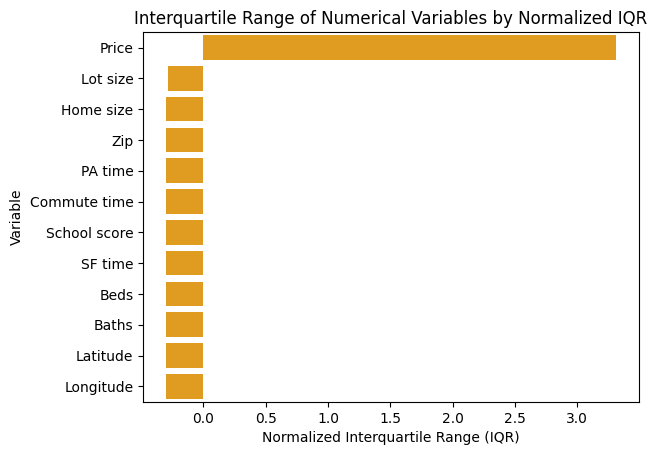

In [20]:
# Find all numerical features
numerical_cols = df.select_dtypes(include=np.number).columns

# Calculate IQR for each numerical variable
iqrs_dict = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    iqrs_dict[col] = Q3 - Q1

# Calculate mean and standard deviation of IQRs for normalization
iqr_values_list = list(iqrs_dict.values())
iqr_mean = np.mean(iqr_values_list)
iqr_stdev = np.std(iqr_values_list)

# Normalize the IQR values
iqr_norm = {k: (v - iqr_mean) / iqr_stdev for k, v in iqrs_dict.items()}

# Sort the normalized IQRs
sorted_iqr_norm_list = sorted(iqr_norm.items(), key=lambda x: x[1], reverse=True)

# Plot the Pareto chart using the normalized data
show_pareto_chart('Interquartile Range of Numerical Variables by Normalized IQR',
                  'Normalized Interquartile Range (IQR)', 'Variable',
                   [x[1] for x in sorted_iqr_norm_list], [x[0] for x in sorted_iqr_norm_list])

Interpretation:

This vertical bar chart ranks numerical features by their normalized IQR values, sorted descending. The `Price` feature is the most important numerical feature in the dataset when building the ML models.



## Detect outliers with interquartile range (IQR) method

In [21]:
# Compute Q1 (25th percentile) and Q3 (75th percentile) for the Price
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

print(f"Number of outliers detected in 'Price': {len(outliers)}")

Number of outliers detected in 'Price': 473


In [22]:
print(f"Original df shape: {df.shape}")

# Remove outliers from the DataFrame
df = df[~((df['Price'] < lower_bound) | (df['Price'] > upper_bound))]
print(f"df shape after removing outliers: {df.shape}")

Original df shape: (5922, 15)
df shape after removing outliers: (5449, 15)


# Download the cleaned dataset

In [23]:
df.to_csv('cleaned_sf_bayarea_house_prices.csv', index=False)